In [1]:
!pip install tensorflow matplotlib numpy


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [3]:
img_size = 128
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

Found 681 files belonging to 2 classes.
Using 545 files for training.
Found 681 files belonging to 2 classes.
Using 136 files for validation.


In [4]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [5]:
model = models.Sequential([
    data_aug,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.6312 - loss: 0.6709 - val_accuracy: 0.5000 - val_loss: 3.0860
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.7193 - loss: 0.6364 - val_accuracy: 0.6912 - val_loss: 0.5872
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - accuracy: 0.8037 - loss: 0.4280 - val_accuracy: 0.8309 - val_loss: 0.3973
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.8532 - loss: 0.3549 - val_accuracy: 0.8603 - val_loss: 0.3208
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - accuracy: 0.8587 - loss: 0.3688 - val_accuracy: 0.8235 - val_loss: 0.3463
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.8257 - loss: 0.3832 - val_accuracy: 0.8162 - val_loss: 0.4225
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - accuracy: 0.8440 - loss: 0.3540 - val_accuracy: 0.8824 - val_loss: 0.2918
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.8532 - loss: 0.3272 - val_accuracy: 0

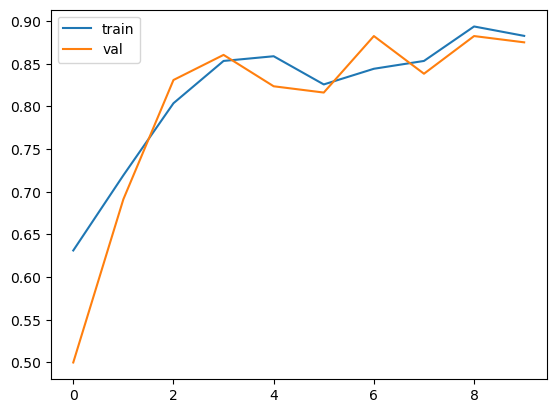

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.show()

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("dataset/pothole/1.jpg", target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Pothole Detected")
else:
    print("No Pothole")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Pothole Detected
